In [3]:
%run analysis_tools.ipynb # might require to install nbformat module
# alternative: use !pip install import_ipynb  and import instead of %run


# we still import the modules here for nicer code completion in IDEs
import itertools
import os
from glob import glob
from more_itertools import only
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib import collections as mc

import numpy as np
from numpy.linalg import norm
from scipy.interpolate import interpn, interp1d

from scipy.signal import find_peaks

import pandas as pd
from tqdm import tqdm

.....
----------------------------------------------------------------------
Ran 5 tests in 0.028s

OK


# Configuration

In [4]:
# this cell defined parameters for use with papermill

dataset = "wildtype"  # choices: wildtype, ltgb1, lamc1 
# dataset = "ltgb1"
# dataset = "lamc1"

prefer_new = True  # if True, use new data if available, otherwise old data


In [5]:
# get filenames and metadata

if dataset == "wildtype":
    inputdir = Path("./data/wildtype")
    outputdir = Path('./output/wildtype')
    prefix = "wt_"
    groupname = "stage"

    pairs = [("epi15", "epi40"), ("epi40", "epi65"), ("epi65", "epi90")]
    order = ["epi15", "epi40", "epi65", "epi90"]


elif dataset == "ltgb1":
    inputdir = Path("./data/ltgb1")
    outputdir = Path('./output/ltgb1del')
    prefix = "ltgb1KO_"
    groupname = "genotype"

    pairs = [("wt", "het"), ("het", "hom"), ("wt", "hom")]
    order = ["wt", "het", "hom"]


elif dataset == "lamc1":
    inputdir = Path("./data/Lamc1")
    outputdir = Path('./output/Lamc1')
    prefix = "lamc1KO_"
    groupname = "genotype"

    pairs = [("wt", "het"), ("het", "hom"), ("wt", "hom")]
    order = ["wt", "het", "hom"]




if dataset == "wildtype":
    fns = inputdir.glob("*/*.npz")
    df = pd.DataFrame({"path": fns})
    df["stage"] = df.path.apply(lambda x: x.parent.name)

elif dataset in ["ltgb1", "lamc1"]:
    fns = inputdir.glob("*/*/output/avg_*.npz")
    # get annotations
    annotations = pd.read_csv(only(inputdir.glob("*samples*.csv")))

    if "folder_name" not in annotations.columns:
        annotations["folder_name"] = annotations["embryoName"]

    # combine with dataset 
    df = pd.DataFrame({"path": fns})
    df["folder_name"] = df.path.apply(lambda p: p.parent.parent.name)
    df = df.merge(annotations[["folder_name", "genotype"]], on="folder_name", how="left")

    df = df.drop_duplicates(subset=["folder_name"],  keep = "last" if prefer_new else "first")


xspan = ( 0.0, 0.8)
yspan = (-0.8, 0.8)

In [6]:
print("Found ", len(df), " embryos for analysis.")

for index, row in df.iterrows():
    print("Analyze file ", row['path'], "\t\t with category ", row[groupname])

Found  36  embryos for analysis.
Analyze file  data/wildtype/epi65/230601_E500_1-1.npz 		 with category  epi65
Analyze file  data/wildtype/epi65/230601_E500_1-3.npz 		 with category  epi65
Analyze file  data/wildtype/epi65/230914_E525_4-6.npz 		 with category  epi65
Analyze file  data/wildtype/epi65/230601_E500_1-2.npz 		 with category  epi65
Analyze file  data/wildtype/epi65/230601_E500_2-1.npz 		 with category  epi65
Analyze file  data/wildtype/epi65/230601_E500_2-2.npz 		 with category  epi65
Analyze file  data/wildtype/epi65/230914_E525_5-2.npz 		 with category  epi65
Analyze file  data/wildtype/epi65/230527_E500_1-2.npz 		 with category  epi65
Analyze file  data/wildtype/epi65/230527_E500_1-3.npz 		 with category  epi65
Analyze file  data/wildtype/epi65/230601_E500_1-10.npz 		 with category  epi65
Analyze file  data/wildtype/epi65/230622_E475_3-2.npz 		 with category  epi65
Analyze file  data/wildtype/epi65/230601_E500_1-8.npz 		 with category  epi65
Analyze file  data/wildtype/ep

In [7]:
list(fns)

[]

# Implementation

In [8]:
os.makedirs(outputdir, exist_ok=True)

In [9]:
xs_unif = np.linspace(*xspan, 100)
ys_unif = np.linspace(*yspan, 200)

In [10]:
# load and rescale data:
df["data"] = df.path.apply(load_rescaled_data)

In [11]:
# interpolate all vectorfields over the xs_unif and ys_unif grid:
df["vecs_unif"] = df.data.apply(
    lambda data: interpolate_vectors(data["xs"],
                                     data["ys"],
                                     data["major_axes"],
                                     data["ellipsoid_radii"],
                                     data["principle_moments"], 
                                     xs_unif, 
                                     ys_unif)
)

In [12]:
%%capture
# compute nematic means per embryo:
df["nematic_mean"] = df.vecs_unif.apply(compute_nematic_mean)

In [13]:
ngroups = len(np.unique(df[groupname]))
print(f"Group according to '{groupname}' with {ngroups} groups")

Group according to 'stage' with 4 groups


In [14]:
%%capture
# nematic means per stages 
group_mean = {group: compute_nematic_mean(np.concatenate(df_stage.vecs_unif.values)) 
                    for (group, df_stage) in df.groupby(groupname)
                    }

In [15]:
# compute average boundary per stage
stages_avg_boundary = {groupname: average_boundary(df_stage.data.values, "avg", groupname) 
                       for (groupname, df_stage) in df.groupby(groupname)}

# Plots

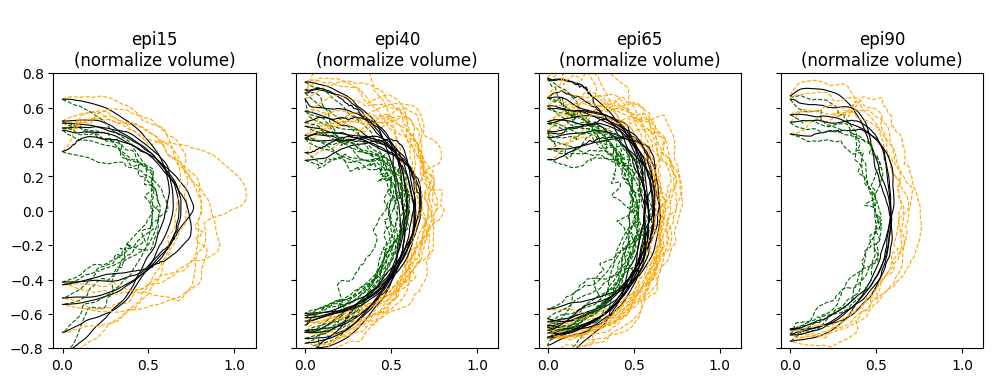

In [16]:
# plot stage averages
fig, axs = plt.subplots(1, ngroups, figsize=(ngroups*3,14), sharey = True, sharex = True)

for (k, (grp, df_stage)) in enumerate(df.groupby(groupname)):
    

    ax = axs[k]
    ax.set_title(f'\n{grp}\n(normalize volume)')
    ax.set_aspect("equal")
    ax.set_ylim(*yspan)
    
    for fn in df_stage.path.values:
        plot_all_boundaries(ax, load_rescaled_data(fn)) 

plt.savefig(outputdir / (prefix + "sections.png"))
plt.show()

# Weighted Axes

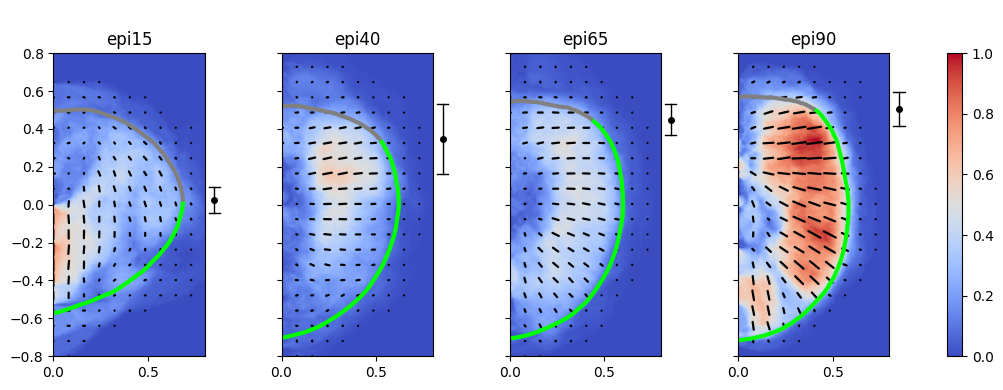

In [17]:
for normed in [False]:
    fig, axs = plt.subplots(1,ngroups, figsize=(3*ngroups,4), sharex=True, sharey=True)

    vmax = np.max([np.max(norm(nematic_field, axis = -1)) for (group, nematic_field) in group_mean.items()])

    for (k, (group, nematic_field)) in enumerate(group_mean.items()):
        
        ax = axs[k]
        ax.set_title(f'\n{group}')

        norms = norm(nematic_field, axis = -1) / vmax  # this norm is computed using the 3D vectors!

        if normed:
            nematic_field = nematic_field / norms[..., np.newaxis] / 2  # normalize the vector field

        im = ax.imshow(norms.T, extent=[*xspan, *yspan], origin='lower', cmap='coolwarm', vmax = 1.0, vmin = 0.0)
        plot_axes(ax, xs_unif, ys_unif, nematic_field / vmax, steps = (10, 10), l = 0.04)

        # cut plane heights: 
        df_stage = df.loc[df[groupname] == group]

        # for stage_data in df_stage.data.values:
        #     ax.hlines([stage_data["cut_plane_height"]], *xspan, color = "white", linestyle = ":", linewidth = 2, alpha = 0.5)

        # uncomment these lines to plot individual embryo boundaries
        # for data in df.loc[df[groupname] == group].data.values:
            # plot_boundary(ax, data, "avg", color = "black", alpha = 0.5, linewidth = 1.5, linestyle = "--")

        cut = np.mean([data["cut_plane_height"] for data in df_stage.data.values])
        cut_std = np.std([data["cut_plane_height"] for data in df_stage.data.values])
        cut_wdt = 0.03

        xdot = 0.85
        ax.plot([xdot], [cut], marker = "o", color = "black", markersize = 4, clip_on = False)
        ax.plot([xdot,xdot], [cut + cut_std, cut - cut_std], color = "black", linewidth = 1, clip_on = False)
        ax.plot([xdot-cut_wdt,xdot+cut_wdt], [cut + cut_std, cut + cut_std], color = "black", linewidth = 1, clip_on = False)
        ax.plot([xdot-cut_wdt,xdot+cut_wdt], [cut - cut_std, cut - cut_std], color = "black", linewidth = 1, clip_on = False)

        # averaged embryo boundary 
        angls, mags, X, Y  = stages_avg_boundary[group]
        mask = Y < cut
        ax.plot(X[mask], Y[mask], linewidth = 3.0, linestyle = "solid", color = "lime")
        ax.plot(X[np.logical_not(mask)], Y[np.logical_not(mask)], linewidth = 3.0, linestyle = "solid", color = "gray")

        ax.set_xlim(*xspan)
        ax.set_ylim(*yspan)


        # ax.vlines([x_line], *yspan, color = "white", linestyle = ":", linewidth = 2)
        # ax.vlines([y_line], *xspan, color = "white", linestyle = ":", linewidth = 2)

    fig.tight_layout()
    fig.colorbar(im, ax = axs)

    postfix = "_normalized" if normed else ""
    fig.savefig(outputdir / (f"{prefix}nematic_averages_per_stage{postfix}.png"))
    fig.savefig(outputdir / (f"{prefix}nematic_averages_per_stage{postfix}.pdf"))

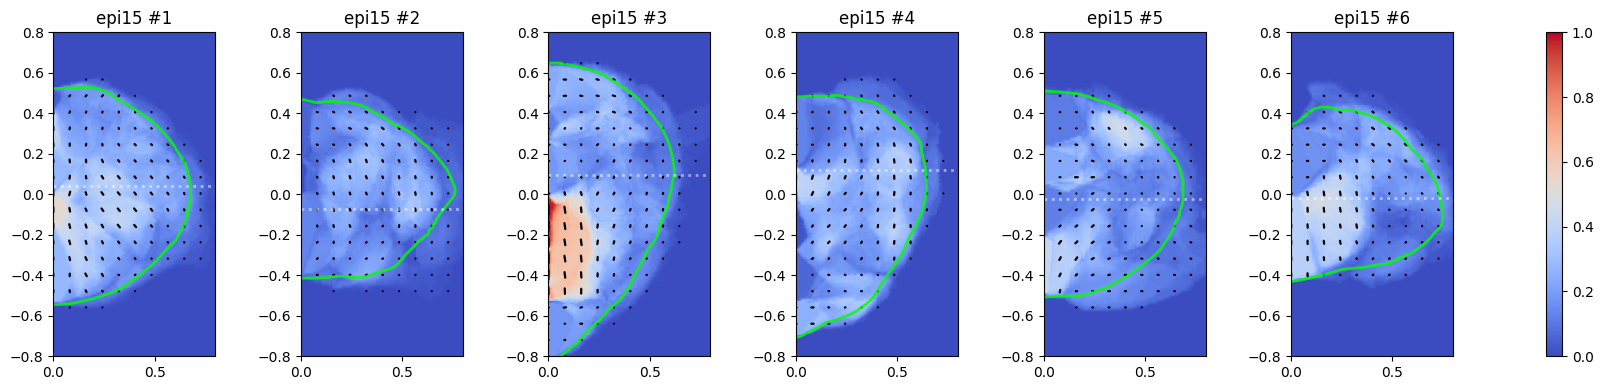

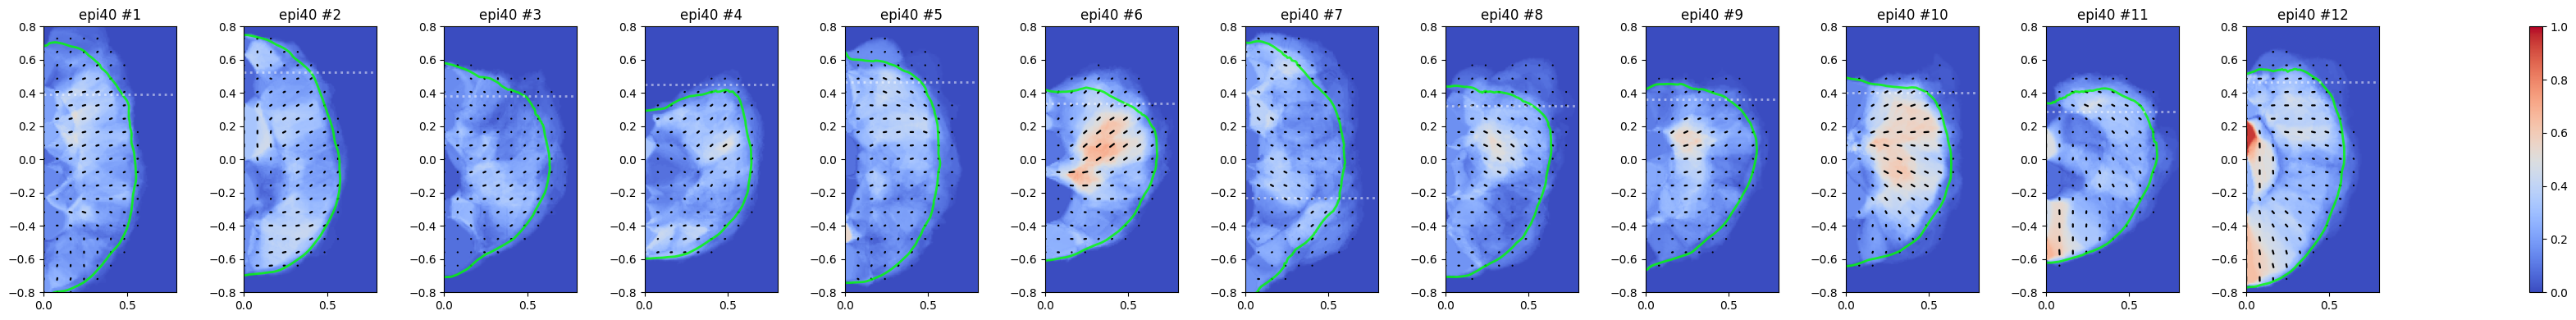

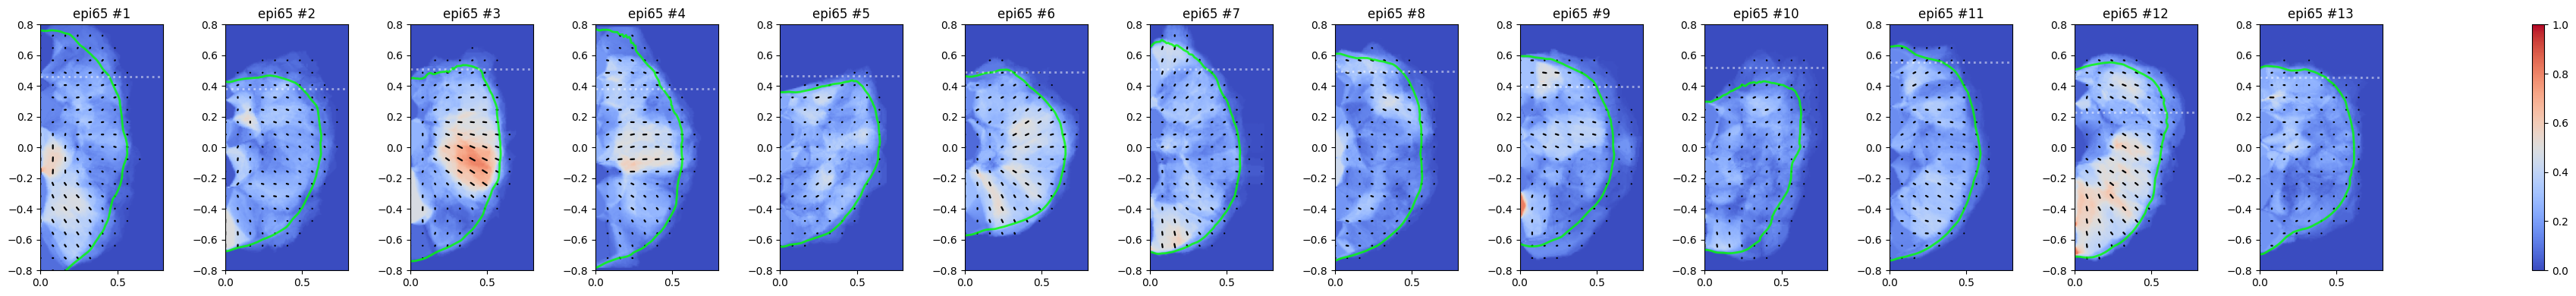

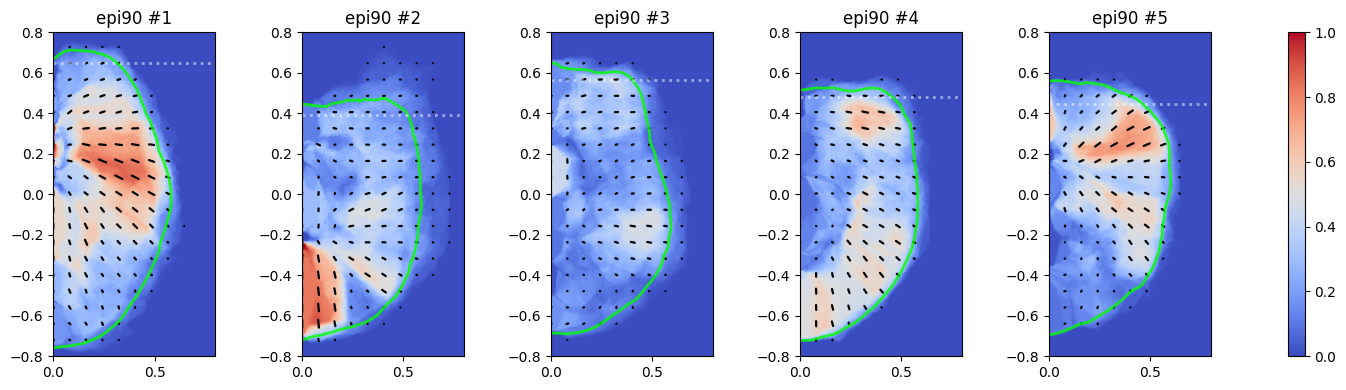

In [18]:
for normed in [False]:
    vmax_embryo = np.max([np.max(norm(nm,axis=-1)) for nm in df.nematic_mean.values])

    for (k, (group, df_stage)) in enumerate(df.groupby(groupname)):

        n_embryo = df_stage.shape[0]

        fig, axs = plt.subplots(1, n_embryo, figsize=(1 + 3 * n_embryo,4))

        for (l, (data, nematic_field)) in enumerate(zip(df_stage.data.values, df_stage.nematic_mean.values)):
            
            ax = axs[l]
            ax.set_title(f'{group} #{l+1}')

            norms = norm(nematic_field, axis = -1) / vmax_embryo  # this norm is computed using the 3D vectors!

            if normed:
                nematic_field = nematic_field / norms[..., np.newaxis]

            im = ax.imshow(norms.T, extent=[*xspan, *yspan], origin='lower', cmap='coolwarm', vmax = 1, vmin = 0)
            plot_axes(ax, xs_unif, ys_unif, nematic_field, steps = (10, 10), l = 0.04)

            plot_boundary(ax, data, "avg", color = "lime", alpha = 0.8, linewidth = 2.0, linestyle = "solid")

            ax.hlines([data["cut_plane_height"]], *xspan, color = "white", linestyle = ":", linewidth = 2, alpha = 0.5)

            ax.set_xlim(*xspan)
            ax.set_ylim(*yspan)

        fig.tight_layout()
        fig.colorbar(im, ax = axs)
        group_fn = group.replace("/", "_")
        postfix = "_normalized" if normed else ""
        fig.savefig(outputdir / f"{prefix}rotational_nematic_averages_group={group_fn}{postfix}.png")
        fig.savefig(outputdir / f"{prefix}rotational_nematic_averages_group={group_fn}{postfix}.pdf")


In [19]:
vmax, vmax_embryo, df[groupname][ np.argmax(np.array([np.max(norm(nm,axis=-1)) for nm in df.nematic_mean.values])) ]

(np.float64(0.2520323348458024), np.float64(0.5643114765740124), 'epi90')

In [20]:
# print summary table of id to full embryo name

# create summary table of embryo filename, embryo number in plot (e.g. 1 2 3 per stage)
per_stage_ids = [] 
df.sort_values(by = groupname, inplace = True)
for i, (stage, df_stage) in enumerate(df.groupby(groupname)):
    per_stage_ids += [j+1 for j in range(len(df_stage))]

df_ids = pd.DataFrame({"filename": [str(x).split(os.sep)[-3] for x in df.path], "type": df[groupname].values, "embryo_number": per_stage_ids})
df_ids.to_csv(outputdir / f"{prefix}embryo_ids.csv", index = False)
df_ids

,filename,type,embryo_number
0,wildtype,epi15,1
1,wildtype,epi15,2
2,wildtype,epi15,3
3,wildtype,epi15,4
4,wildtype,epi15,5
5,wildtype,epi15,6
6,wildtype,epi40,1
7,wildtype,epi40,2
8,wildtype,epi40,3
9,wildtype,epi40,4


In [21]:
df["number_of_cells"] = df.data.apply(lambda d: len(np.unique(d["cell_labels"]))-1)

vmax_embryo = np.max([np.max(norm(nm,axis=-1)) for nm in df.nematic_mean.values])
df["nematic_norm_field"] = df.nematic_mean.apply(lambda nf: norm(nf, axis = 2))
df["nematic_norm_field"] = df["nematic_norm_field"] / vmax_embryo

df["averageExpData"] = df.apply(lambda row: averageExpData(row["nematic_norm_field"].T, xs_unif, ys_unif, row["data"]["embryo_X"], row["data"]["embryo_Y"]), axis = 1)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

epi15 vs. epi40: Mann-Whitney-Wilcoxon test two-sided, P_val:5.290e-02 U_stat=1.500e+01
epi40 vs. epi65: Mann-Whitney-Wilcoxon test two-sided, P_val:7.237e-01 U_stat=8.500e+01
epi65 vs. epi90: Mann-Whitney-Wilcoxon test two-sided, P_val:9.804e-03 U_stat=7.000e+00


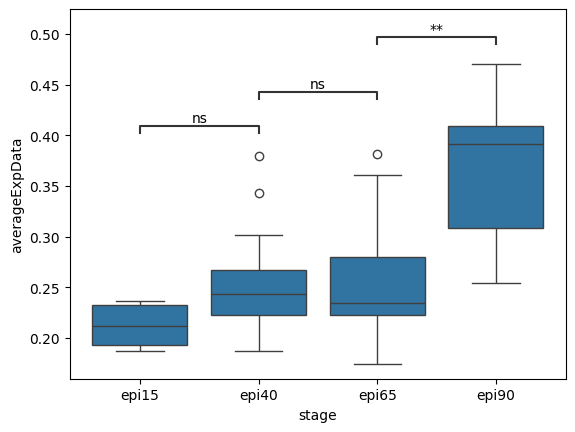

In [22]:
g = sns.boxplot(data=df, x = groupname, y = "averageExpData")

# pairs=[("hom", "wt/het")]
# annotator = Annotator(g, pairs, data=df, x=groupname, y="averageExpData", order=["hom", "wt/het"])

annotator = Annotator(g, pairs, data=df, x=groupname, y="averageExpData", order=order)

annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.savefig(outputdir / f"{prefix}{groupname}_vs_avg_order_boxplot.pdf")
plt.savefig(outputdir / f"{prefix}{groupname}_vs_avg_order_boxplot.png")

In [32]:
df_avg = df.loc[:, (groupname, "averageExpData", "number_of_cells")]
df_avg.to_csv(outputdir / f"{prefix}averageExpData.csv")

ERROR! Session/line number was not unique in database. History logging moved to new session 198


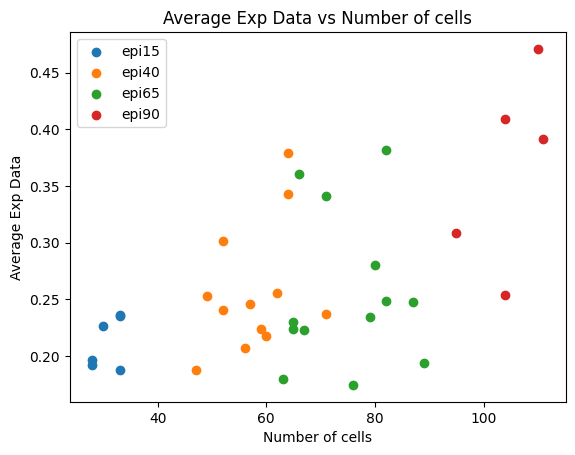

In [34]:
colors = ["C"+str(k) for k in range(ngroups)]

for (k, (group, df_stage)) in enumerate(df.groupby(groupname)):
    plt.scatter(df_stage.number_of_cells, df_stage.averageExpData, label = group, color = colors[k], alpha = 1.0)

plt.xlabel("Number of cells")
plt.ylabel("Average Exp Data")
plt.title("Average Exp Data vs Number of cells")

plt.legend()
plt.savefig(outputdir / (prefix + "avgExpData_vs_number_of_cells.png"))
plt.show()